In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal

In [2]:
class Intent(TypedDict):
    question: str
    answer: str
    intent: Literal["Explain","Code","Quiz","Other"]
    

In [5]:
llm=ChatOllama(model="llama3.2:1b")

In [4]:
def identify_intent(state:Intent)->Literal["Explain","Code","Quiz","Other"]:
    q=state["question"].strip()
    if "explain" in q.lower():
        return {"intent":"Explain"}
    elif "code" in q.lower():
        return {"intent":"Code"}
    elif "quiz" in q.lower():
        return {"intent":"Quiz"}
    else:
        return {"intent":"Other"}   

In [6]:
def gen_code(state:Intent)->Intent:
    q=state["question"]
    prompt=f"You are a coding expert Generate code in python if user not specific the language for this promblem{q}"
    code=llm.invoke(prompt).content
    return {"question":q,"answer":code,"intent":"Code"}

In [7]:
def gen_explain(state:Intent)->Intent:
    q=state["question"]
    prompt=f"you are a good explain expert explain this question{q} in simple way and answere not more then 100 words"
    explain=llm.invoke(prompt).content
    return {"question":q,"answer":explain,"intent":"Explain"}



In [8]:
def gen_quiz(state:Intent)->Intent:
    q=state["question"]
    prompt=f"you are a senior quiz creater create a quiz for this question{q} in simple way the quiz contain 3 question and 5 fill in the blanks"
    explain=llm.invoke(prompt).content
    return {"question":q,"answer":explain,"intent":"Explain"}

In [10]:
def gen_other(state:Intent)->Intent:
    q=state["question"]
    prompt=f"you are a helpful assistant understand this question{q} and answere in simple way and answere not more then 100 words"
    explain=llm.invoke(prompt).content
    return {"question":q,"answer":explain,"intent":"Explain"}

In [11]:
def check_answer(state:Intent)->Intent:
    return state['intent']

In [12]:
graph=StateGraph(Intent)

In [13]:
graph.add_node("identify_intent",identify_intent)

graph.add_node("gen_code",gen_code)
graph.add_node("gen_explain",gen_explain)
graph.add_node("gen_quiz",gen_quiz)
graph.add_node("gen_other",gen_other)


In [14]:
graph.add_edge(START,"identify_intent")
graph.add_conditional_edges("identify_intent",check_answer,{"Explain":"gen_explain","Code":"gen_code","Quiz":"gen_quiz","Other":"gen_other"})
graph.add_edge("gen_explain",END)
graph.add_edge("gen_code",END)
graph.add_edge("gen_quiz",END)
graph.add_edge("gen_other",END)

app=graph.compile()

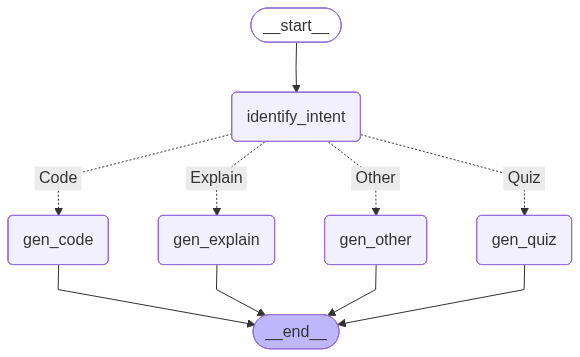

In [15]:
app

In [19]:
resulut=app.invoke({"question":"make a quiz on topic dfs"})
print(resulut)

{'question': 'make a quiz on topic dfs', 'answer': "As a senior quiz creator, I'd be happy to help you with a DFS (Depth-First Search) quiz. Here's a simple quiz containing three questions with five fill-in-the-blank options:\n\n**DFS Quiz**\n\n**Question 1:** A graph has 10 vertices and 12 edges. Which DFS algorithm is most suitable for this problem?\n\nA) Breadth-First Search (BFS)\nB) Depth-First Search (DFS)\nC) Topological Sort\nD) Shortest Path Algorithm\n\n**Answer:** B) Depth-First Search (DFS)\n\n**Question 2:** A computer network has two servers: Server A and Server B. You want to establish a connection between the two servers using DFS. Which server should you connect first?\n\nA) Server A\nB) Server B\nC) Both servers equally\nD) Neither server\n\n**Answer:** D) Neither server\n\n**Question 3:** A company has three departments: Sales, Marketing, and IT. You want to find all the salespeople in each department using DFS. Which algorithm will you use?\n\nA) Breadth-First Searc